In [2]:
# --- Load disk model and M33 center once (for repeated fast use) ---
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u

diskmodel = Table.read("./Kam2017_table4.dat", format='ascii')
m33coord = SkyCoord(ra=23.4621 * u.deg, dec=30.6602 * u.deg)

# --- Your full M33 stellar workflow ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from funcs import *

# === Load and preprocess primary photometric catalog ===
with fits.open("./pandas_goodstar_bright_sr.fits") as hdul:
    data = hdul[1].data
    panda = pd.DataFrame(data.astype(data.dtype.newbyteorder('=')))

panda = panda.rename(columns={'RA': 'RA_DEG', 'Dec': 'DEC_DEG'})


# === Compute deprojected radius with tilted ring model ===
panda = compute_deprojected_radius_tilted_ring(panda, diskmodel, m33coord)


# === Compute non-deprojected (projected) radius ===
distance_kpc = 859
center = m33coord
stars = SkyCoord(ra=panda['RA_DEG'].values * u.deg, dec=panda['DEC_DEG'].values * u.deg)
separation_rad = center.separation(stars).radian
panda['projected_radius_kpc'] = separation_rad * distance_kpc

# === Add CMD photometry ===
panda['color'] = panda['g'] - panda['i']
panda['mag'] = panda['i']

# === Print summary ===
print(f"RA range:  {panda['RA_DEG'].min():.4f}° to {panda['RA_DEG'].max():.4f}°")
print(f"Dec range: {panda['DEC_DEG'].min():.4f}° to {panda['DEC_DEG'].max():.4f}°")
print(f"Deprojected radius: {panda['r_deproj_kpc'].min():.2f} to {panda['r_deproj_kpc'].max():.2f} kpc")
print(f"Projected radius:    {panda['projected_radius_kpc'].min():.2f} to {panda['projected_radius_kpc'].max():.2f} kpc")
print(f"Number of stars: {len(panda):,}")

# === Save processed DataFrame as a new CSV file ===
panda.to_csv("panda_deproj.csv", index=False)

# === Load classified stars for overlay ===
df = load_filtered_fits("/Users/calvinsridhara/Documents/GitHub/M33_Analysis/Tables/m33_vels_stars_inc22B_donedupes.fits")
df = remove_high_vcorr_stars(df)
df = classify_age_groups(df)
df = compute_deprojected_radius_tilted_ring(df, diskmodel, m33coord)
df = df[(df['g'].notnull()) & (df['i'].notnull())].copy()
df['color'] = df['g'] - df['i']
df['mag'] = df['i']

Deprojecting: 100%|████████████████████| 599354/599354 [10:41<00:00, 933.91it/s]


RA range:  19.7848° to 26.9907°
Dec range: 27.5574° to 33.7542°
Deprojected radius: 0.07 to 89.21 kpc
Projected radius:    0.05 to 47.43 kpc
Number of stars: 599,354
Stars with VCORR_STAT > 1000:
         RA_DEG    DEC_DEG     VCORR_STAT
889   23.428667  30.342472  221215.885079
2448  23.458708  30.796500  767133.498926
3327  23.821542  31.219528  648930.752058
4386  22.986750  31.478861   20315.068865
Number of stars in each age group:
age_group
old                  2360
young_unconfirmed    1109
young                 947
int                   816
unclassified           20
Name: count, dtype: int64


Deprojecting: 100%|████████████████████████| 5252/5252 [00:05<00:00, 891.35it/s]


/var/folders/ty/4yhwxltx4bl_b9x2v5y6tsf00000gn/T/ipykernel_32672/816217847.py:62: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


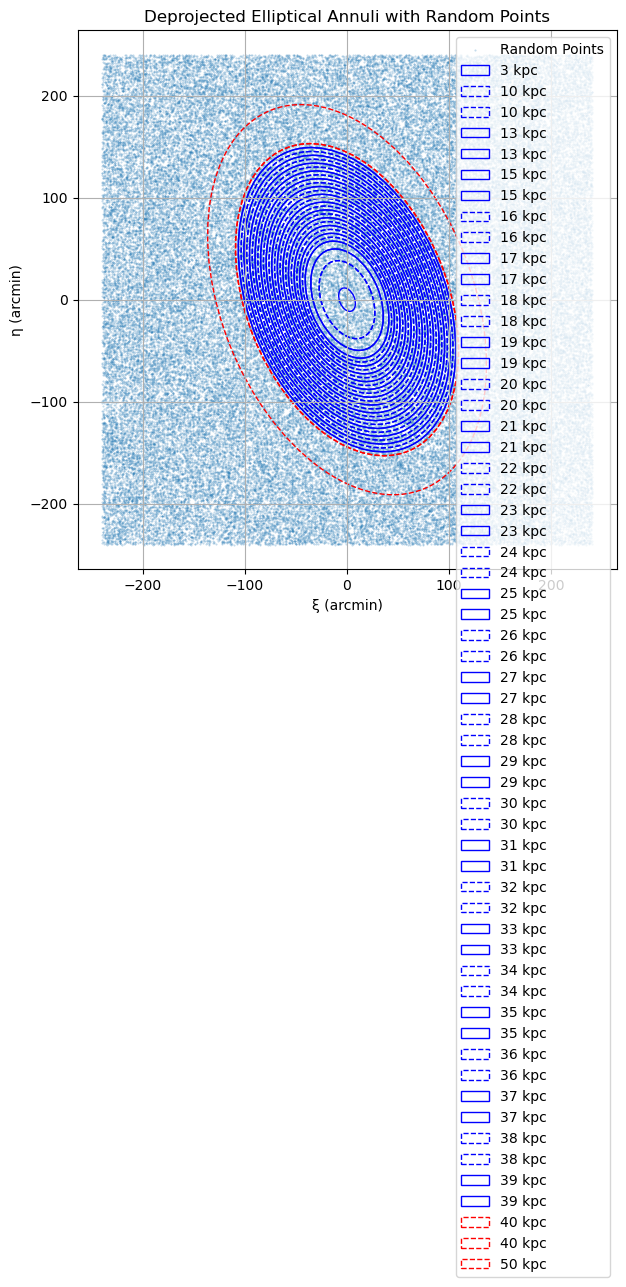


=== Area Comparison for All Bins ===
Bin (kpc)           Analytic Area          Monte Carlo Area     % Diff
---------------------------------------------------------------------------
3-10                       176.01                    172.22      -2.15
10-13                      133.46                    134.64       0.89
13-15                      108.31                    118.22       9.15
15-16                       59.96                     61.78       3.03
16-17                       63.83                     63.94       0.17
17-18                       67.70                     67.68      -0.02
18-19                       71.56                     66.24      -7.44
19-20                       75.43                     77.62       2.90
20-21                       79.30                     76.75      -3.21
21-22                       83.17                     82.37      -0.96
22-23                       87.04                     86.69      -0.40
23-24                       90.91 

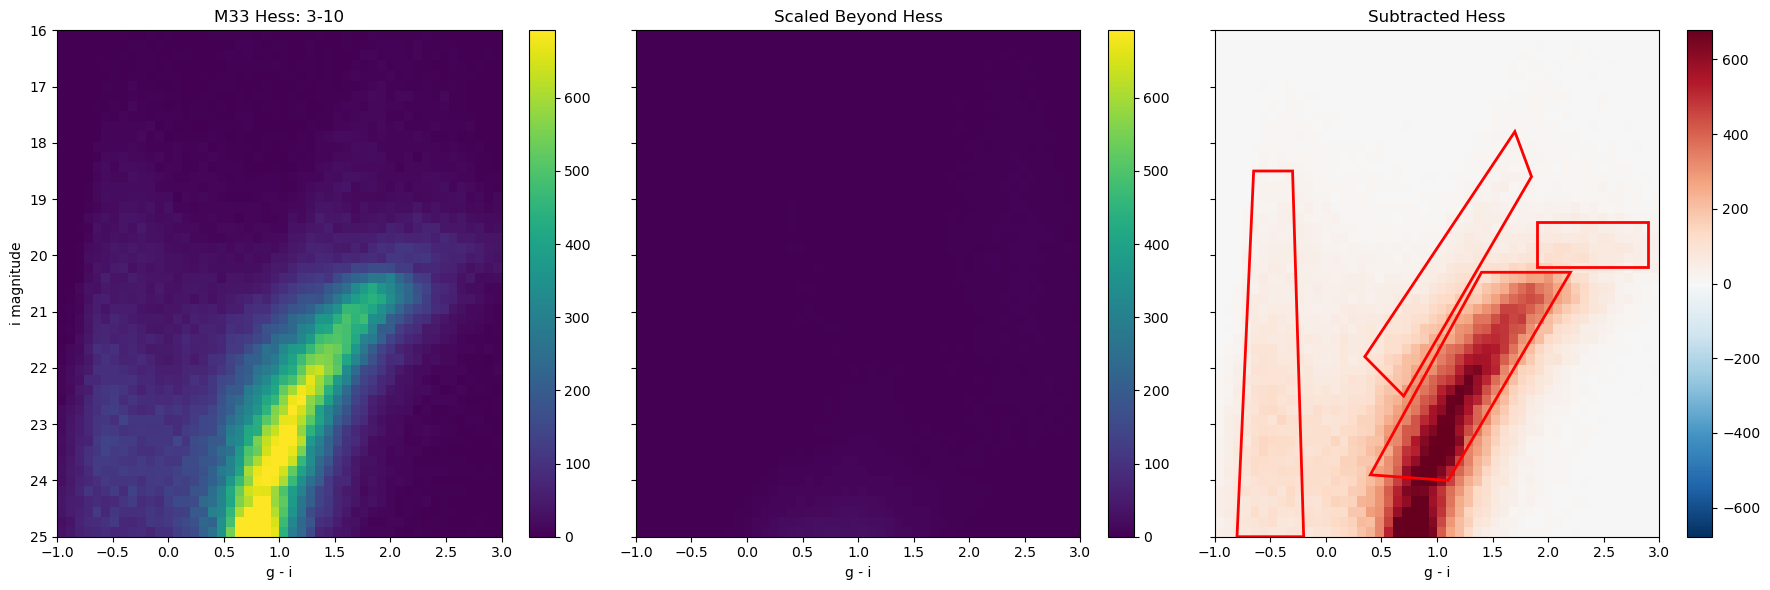

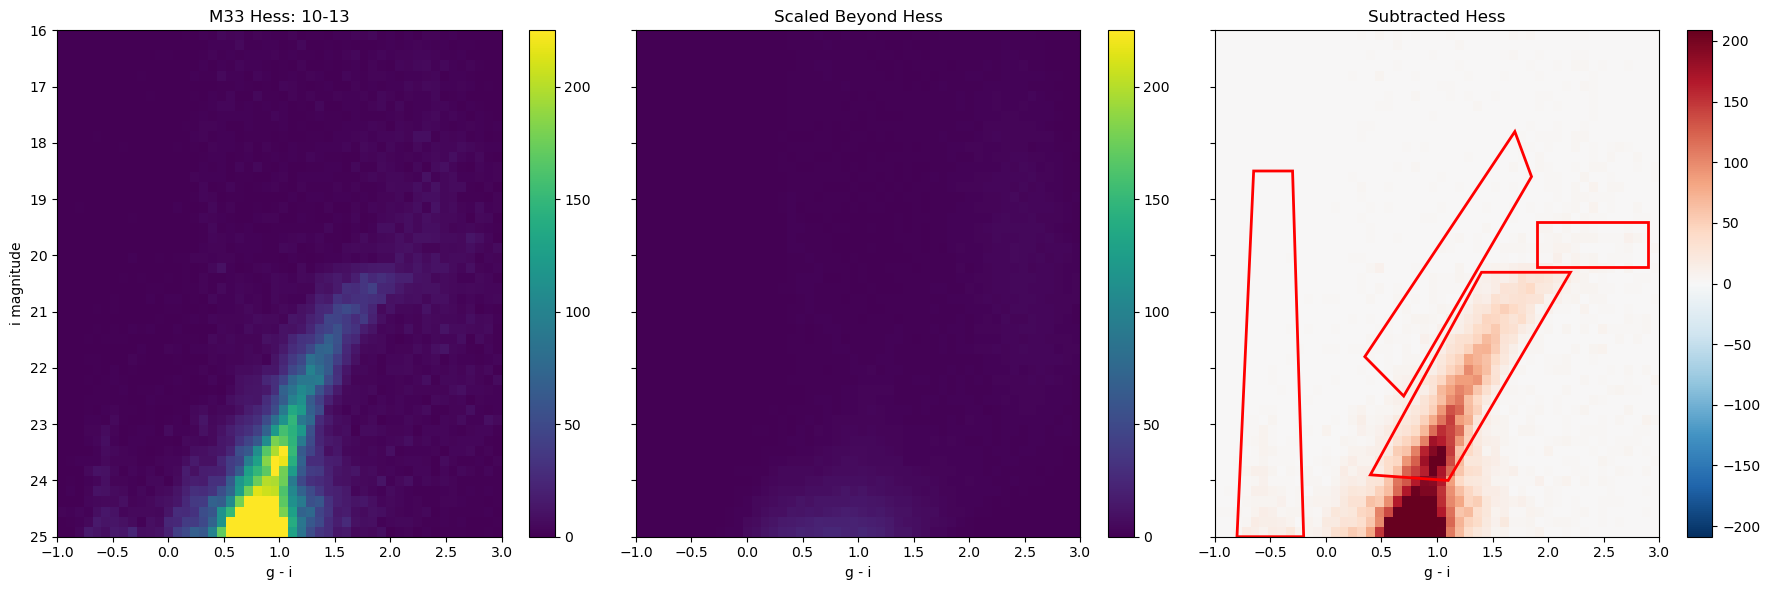

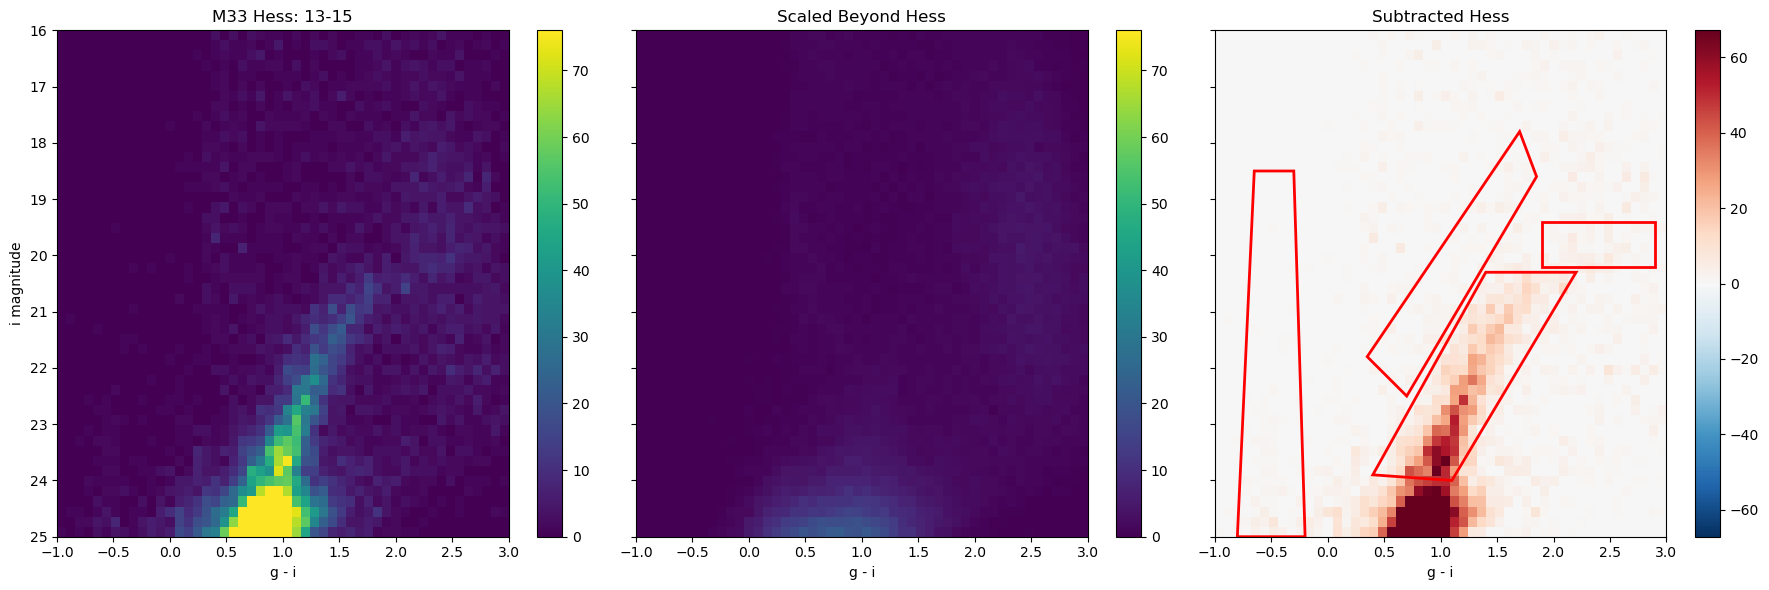

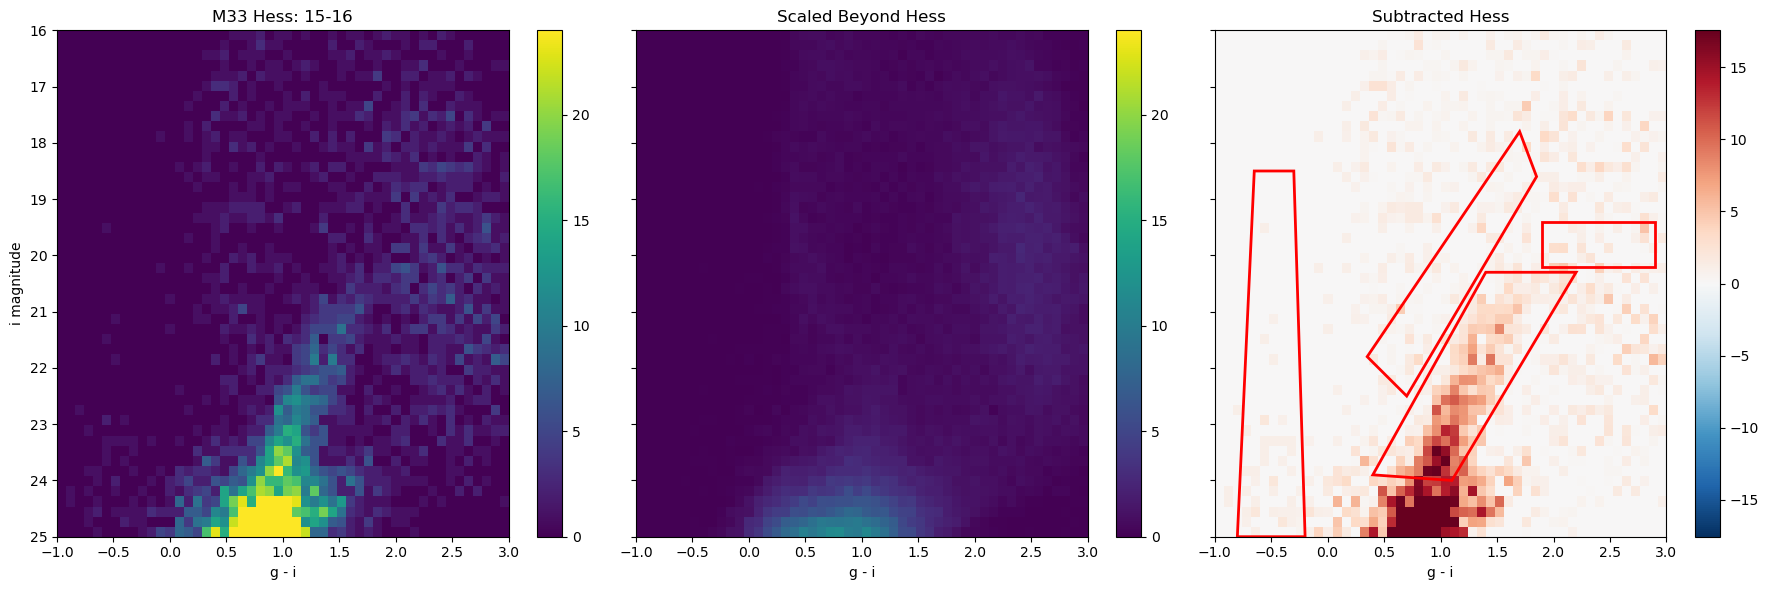

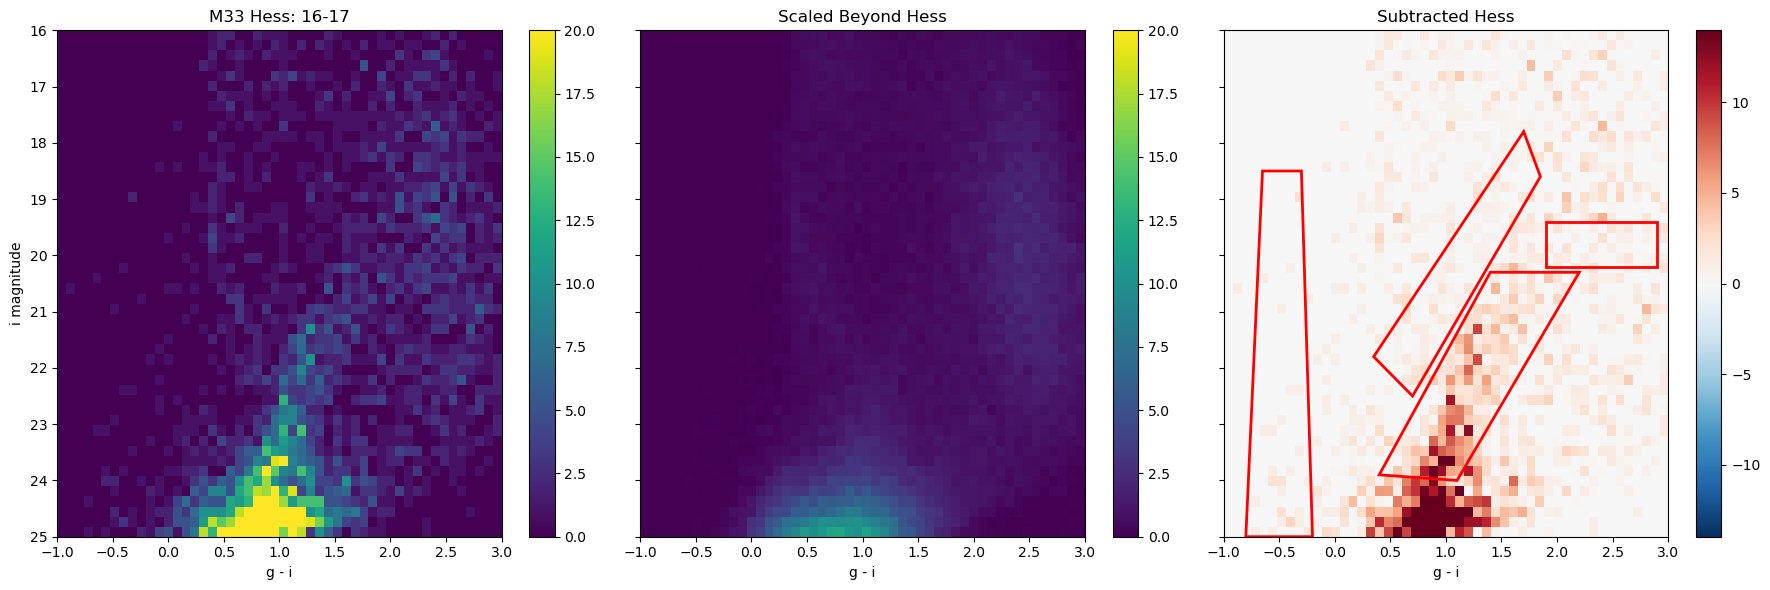

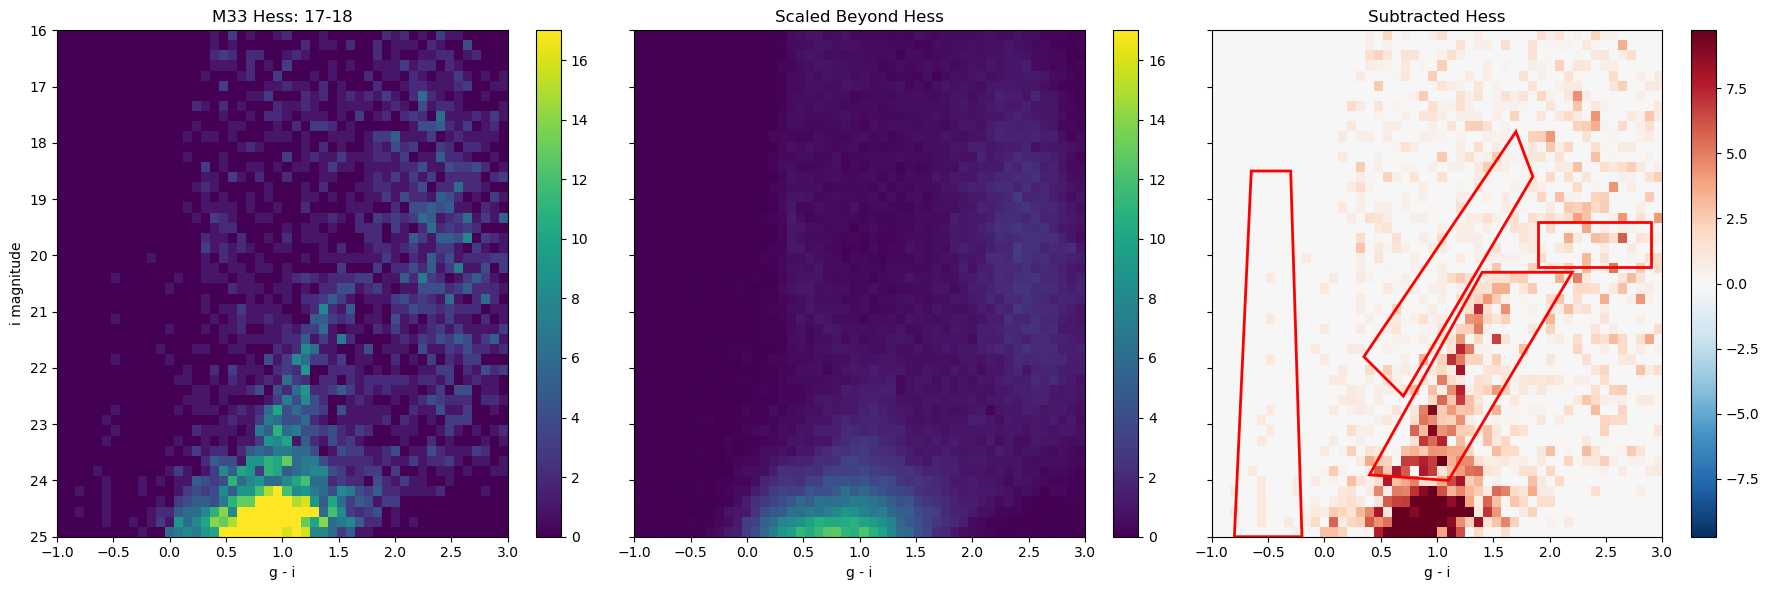

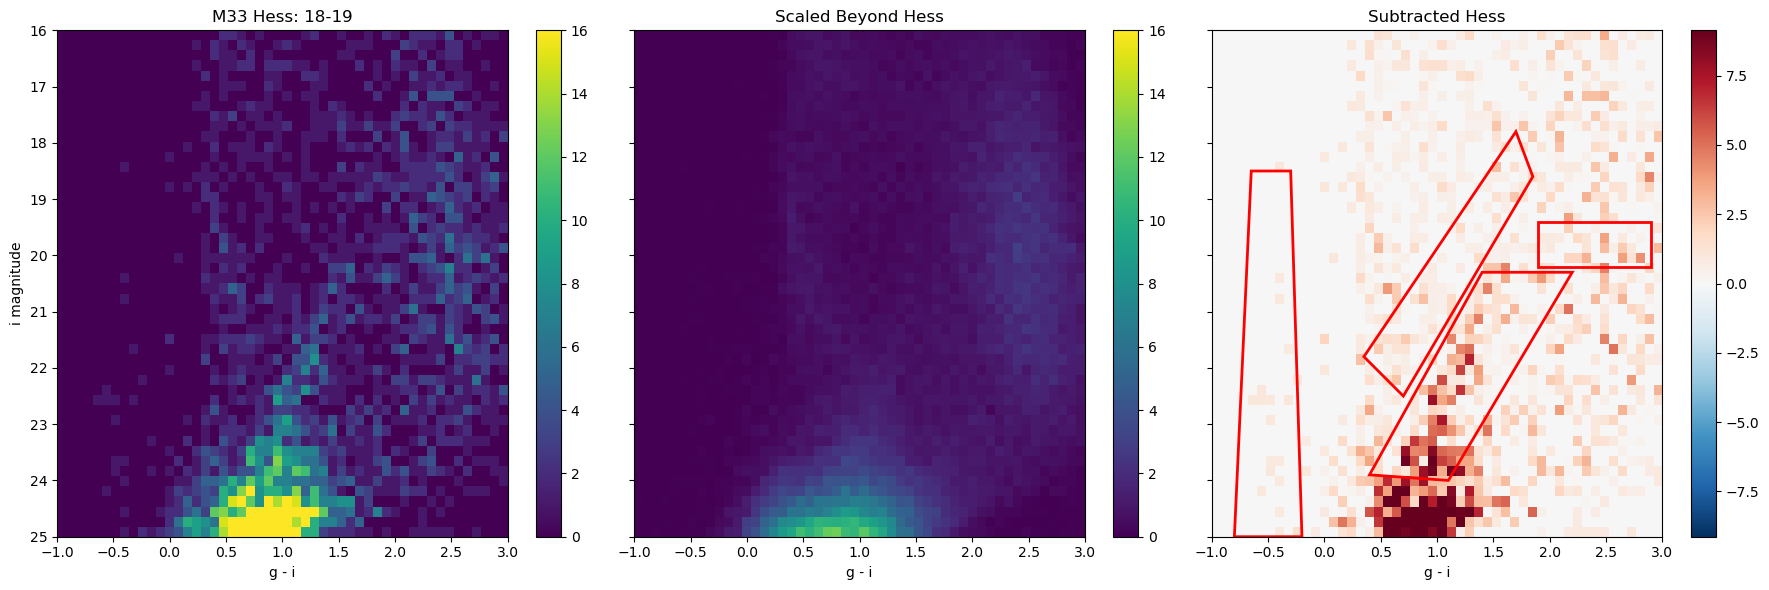

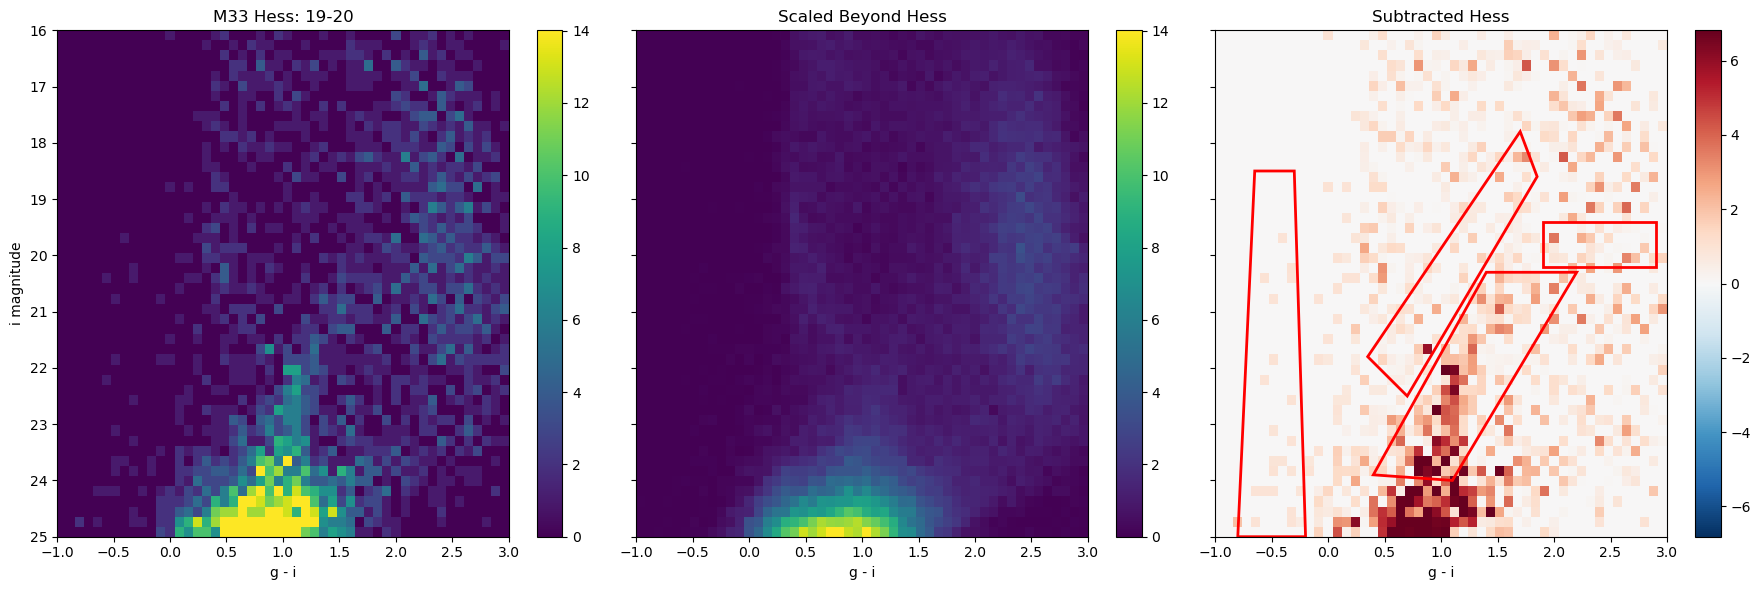

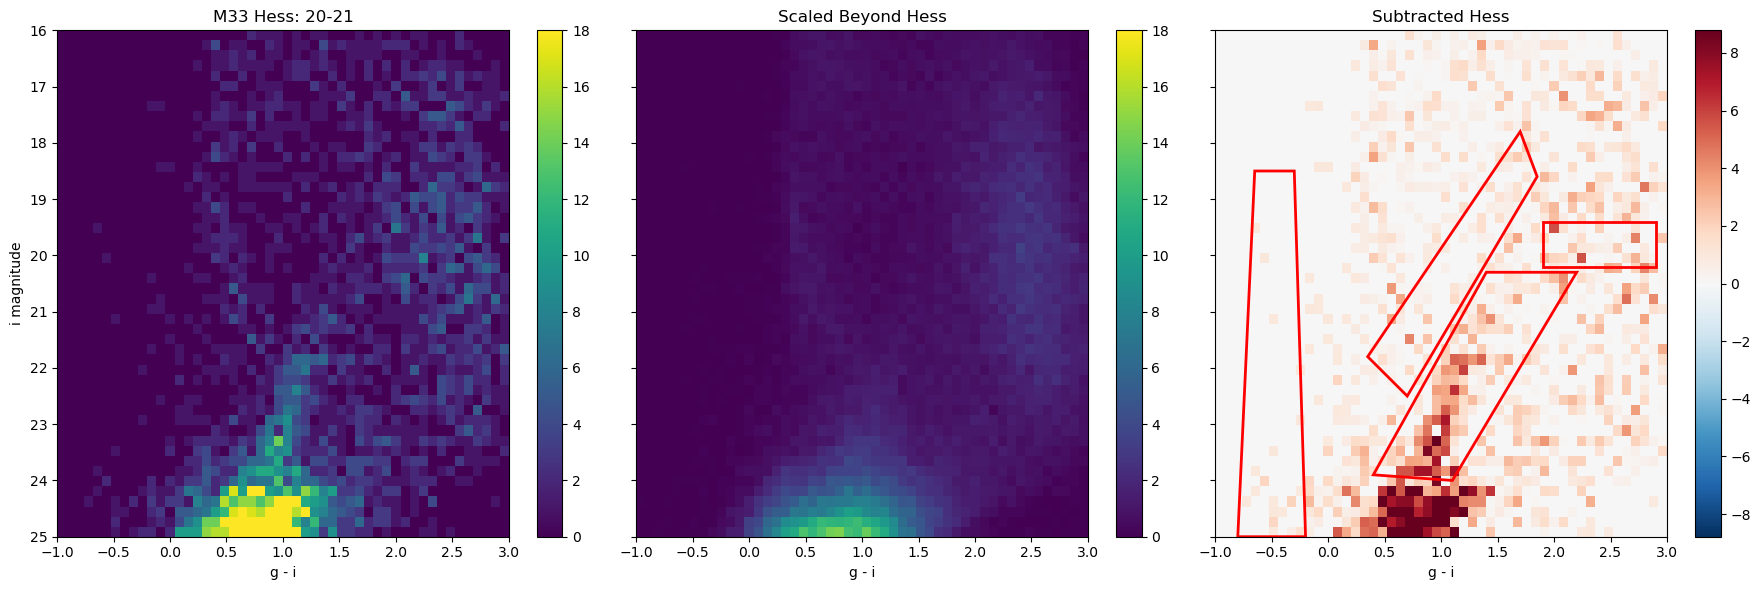

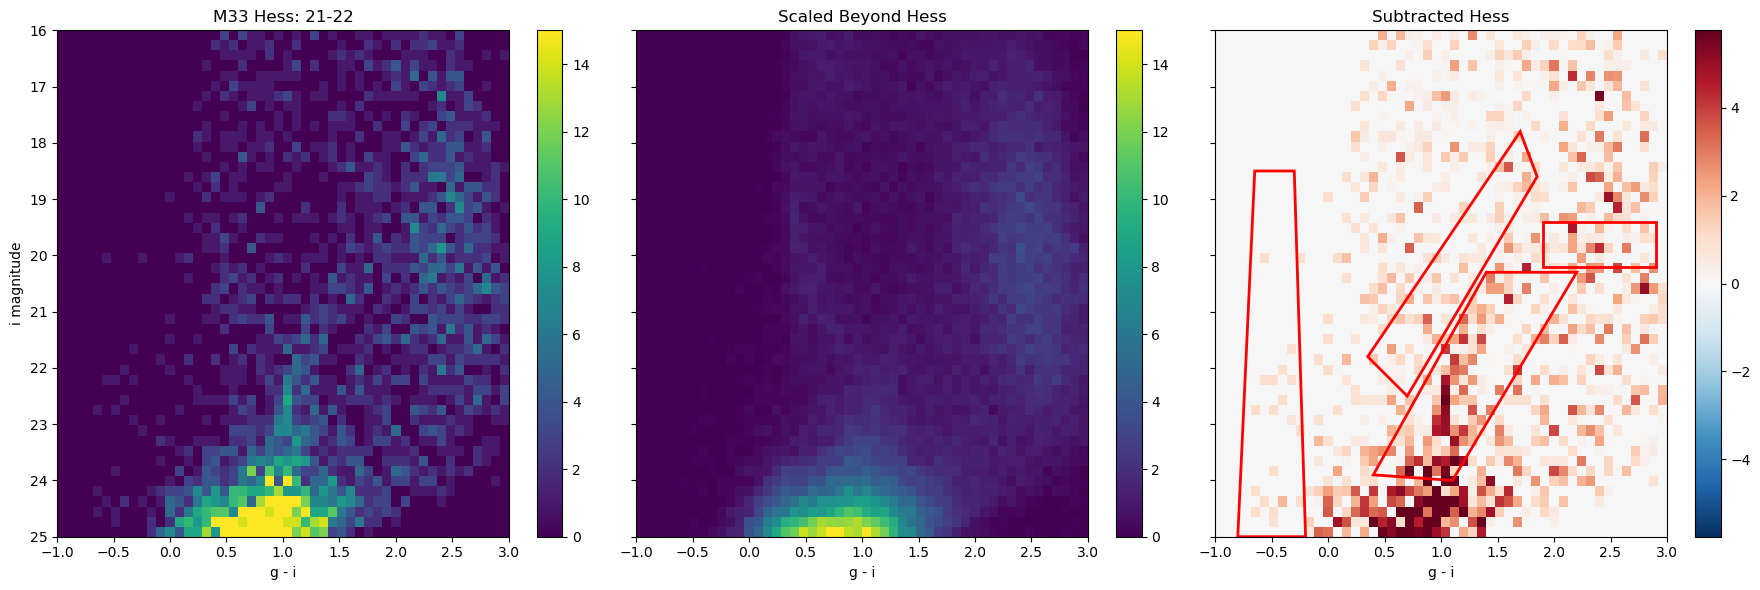

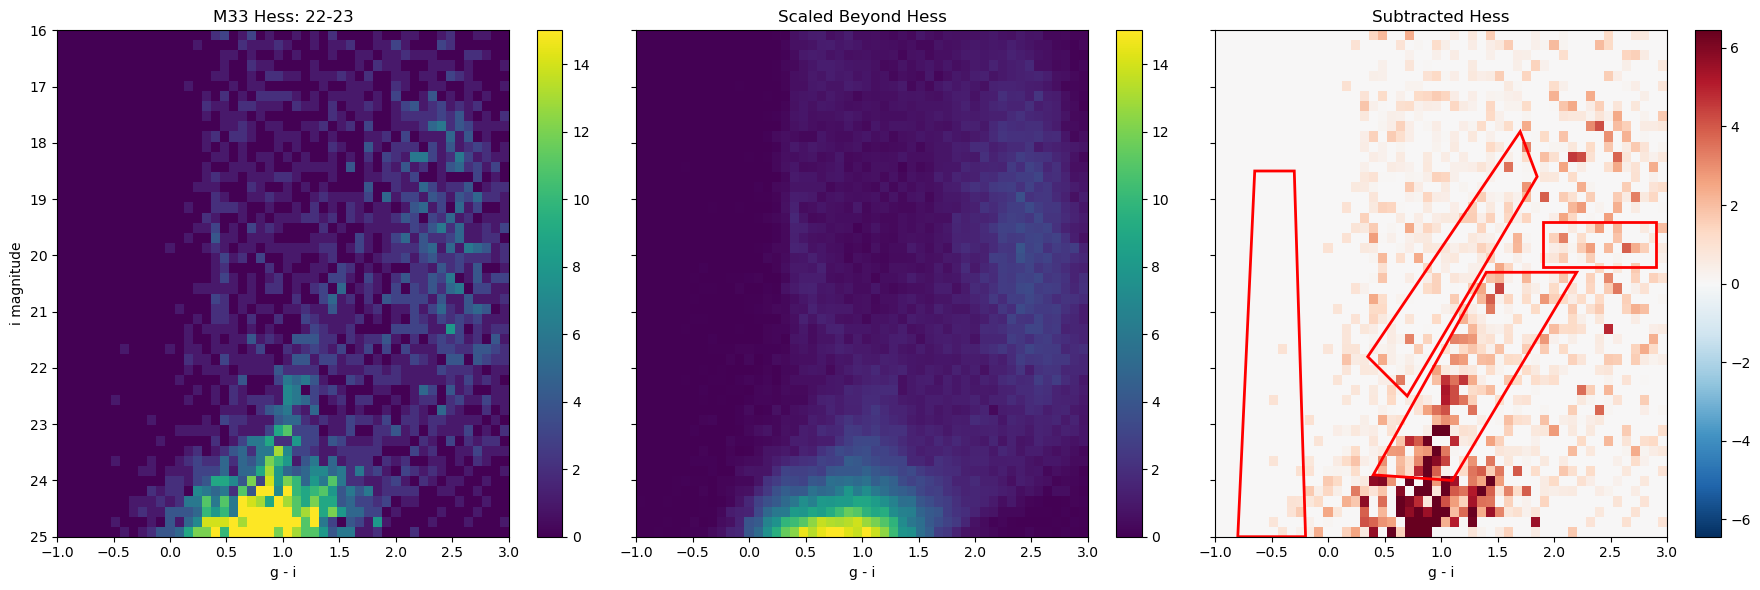

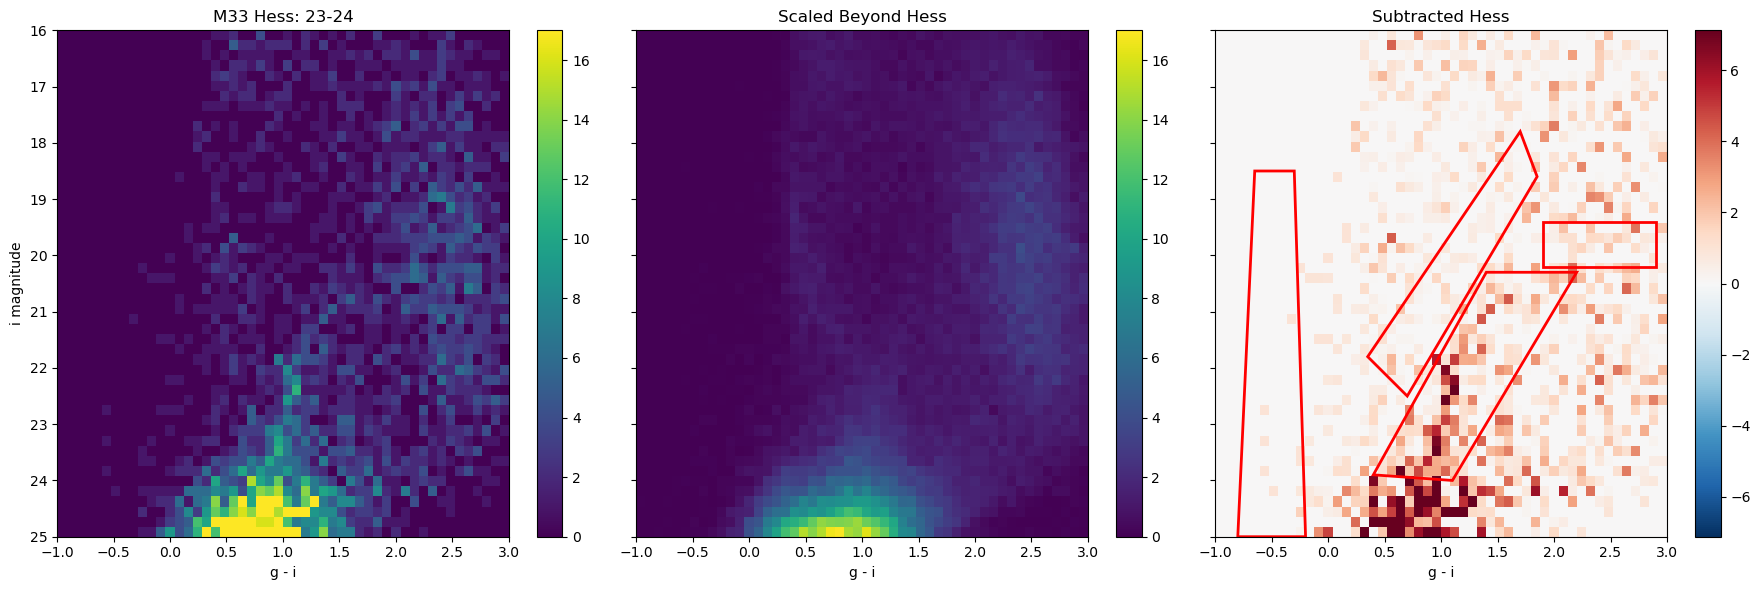

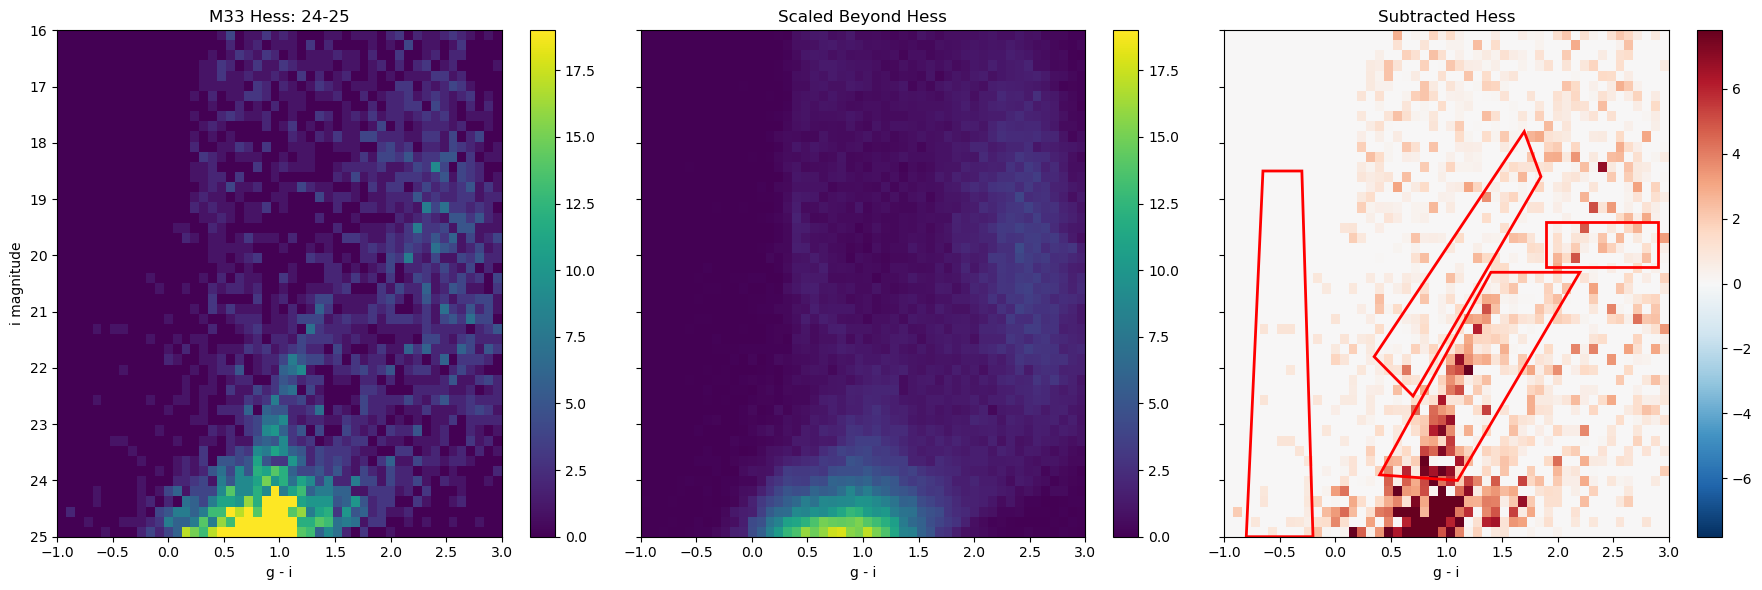

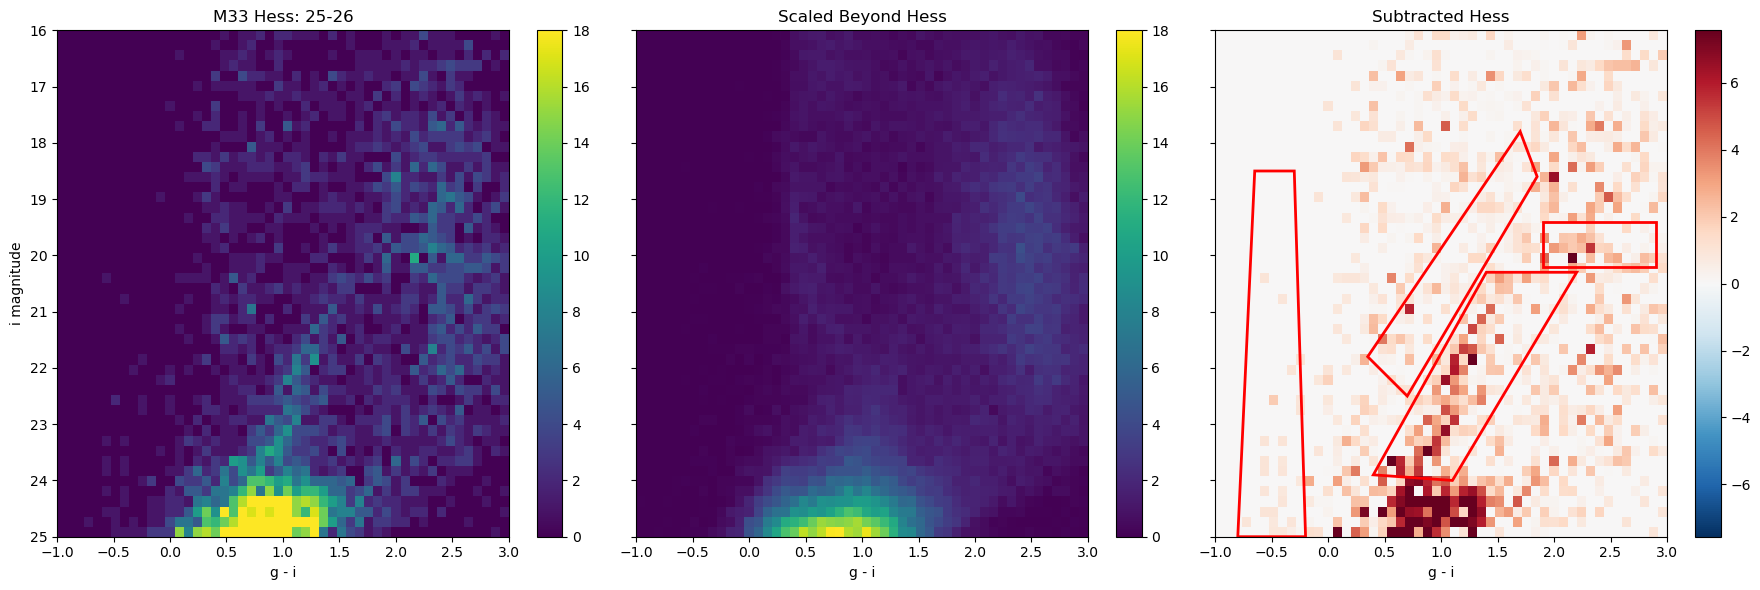

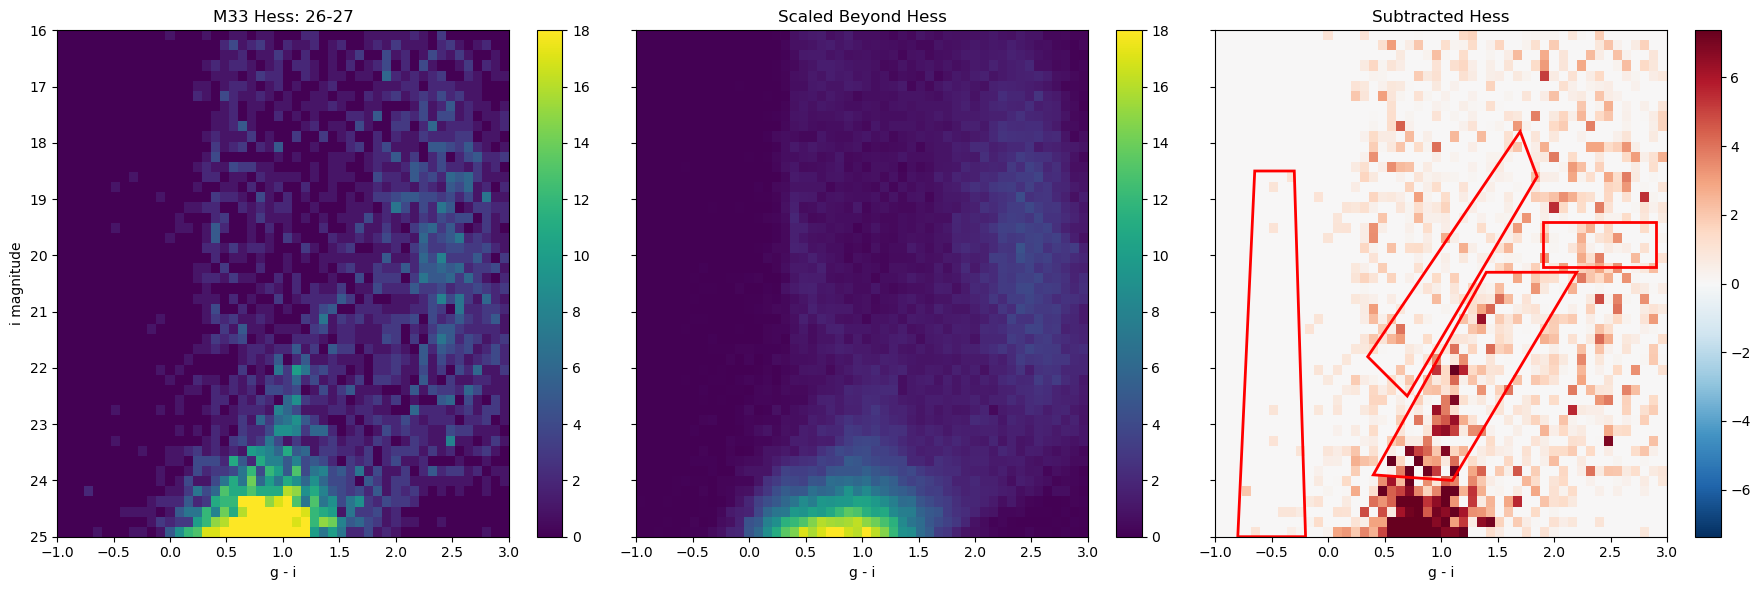

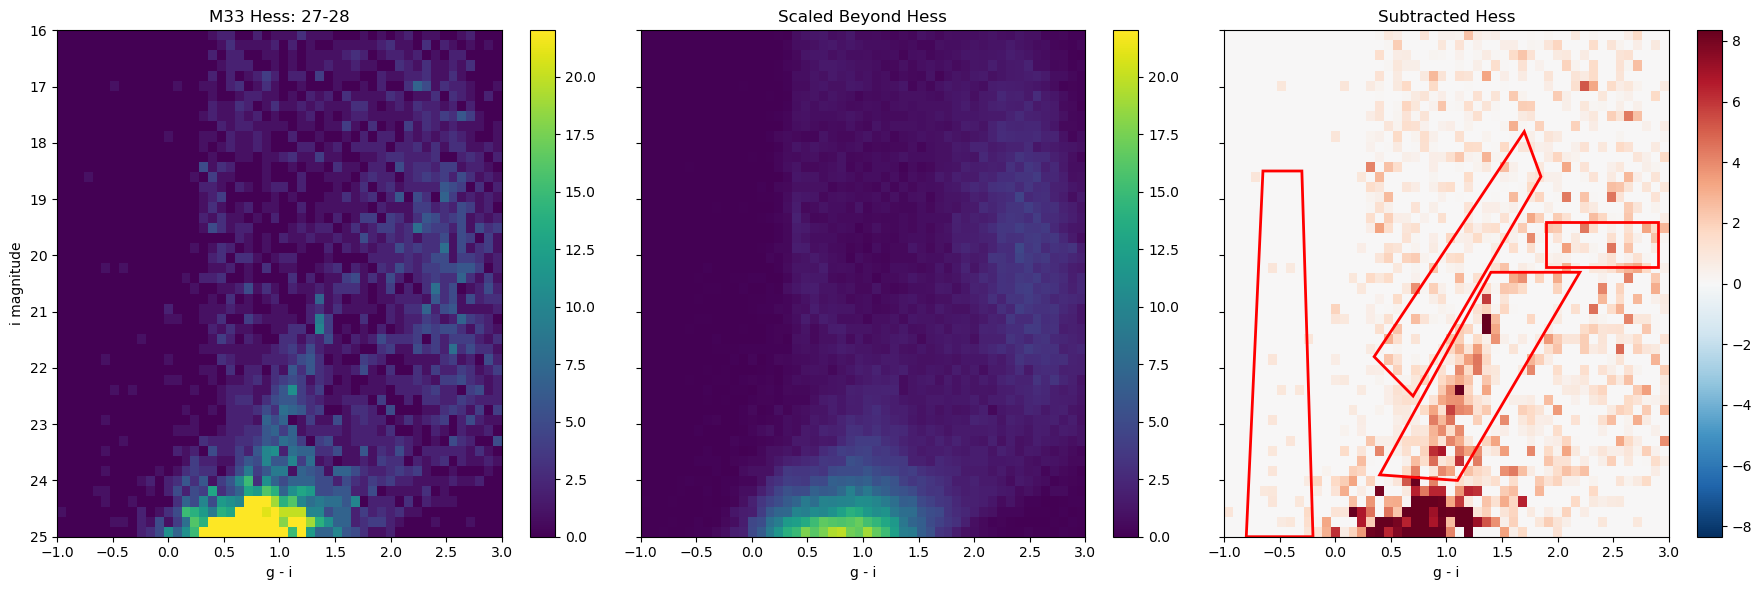

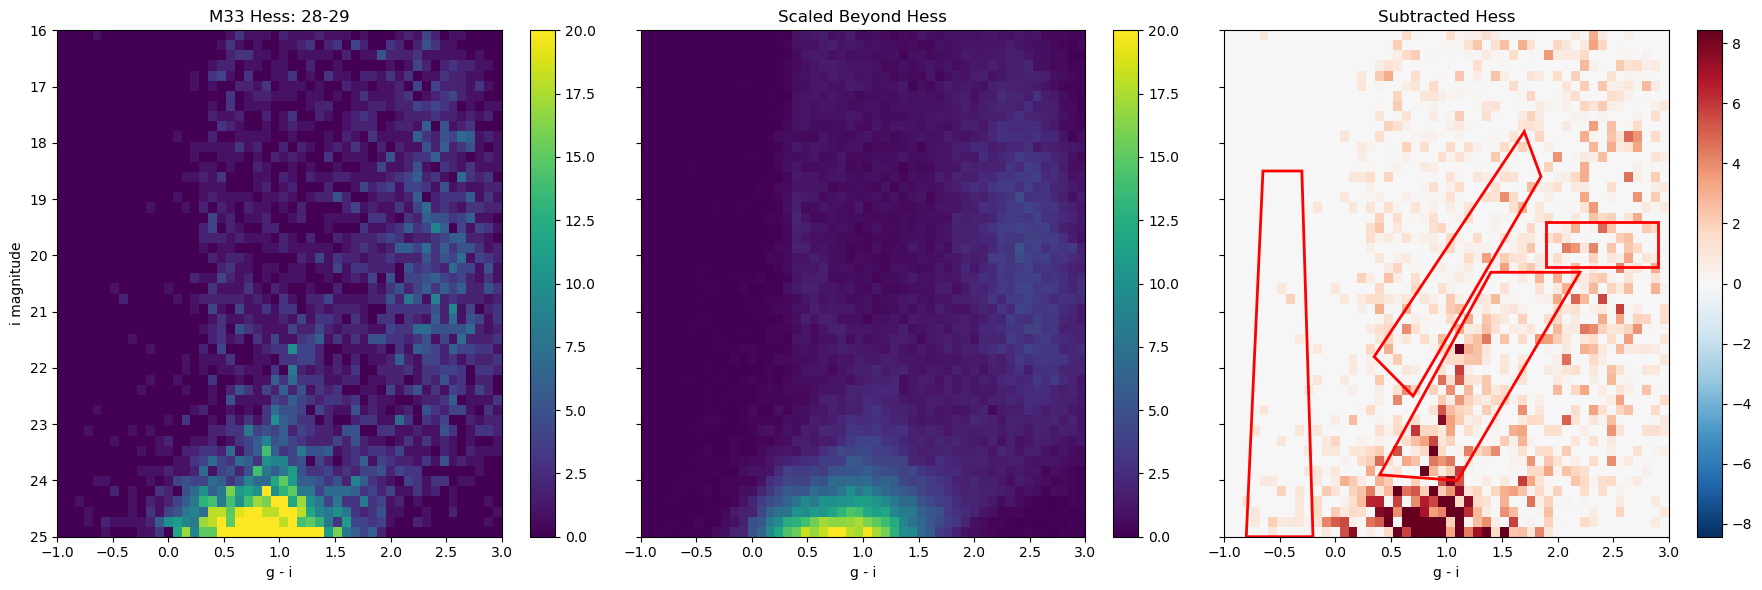

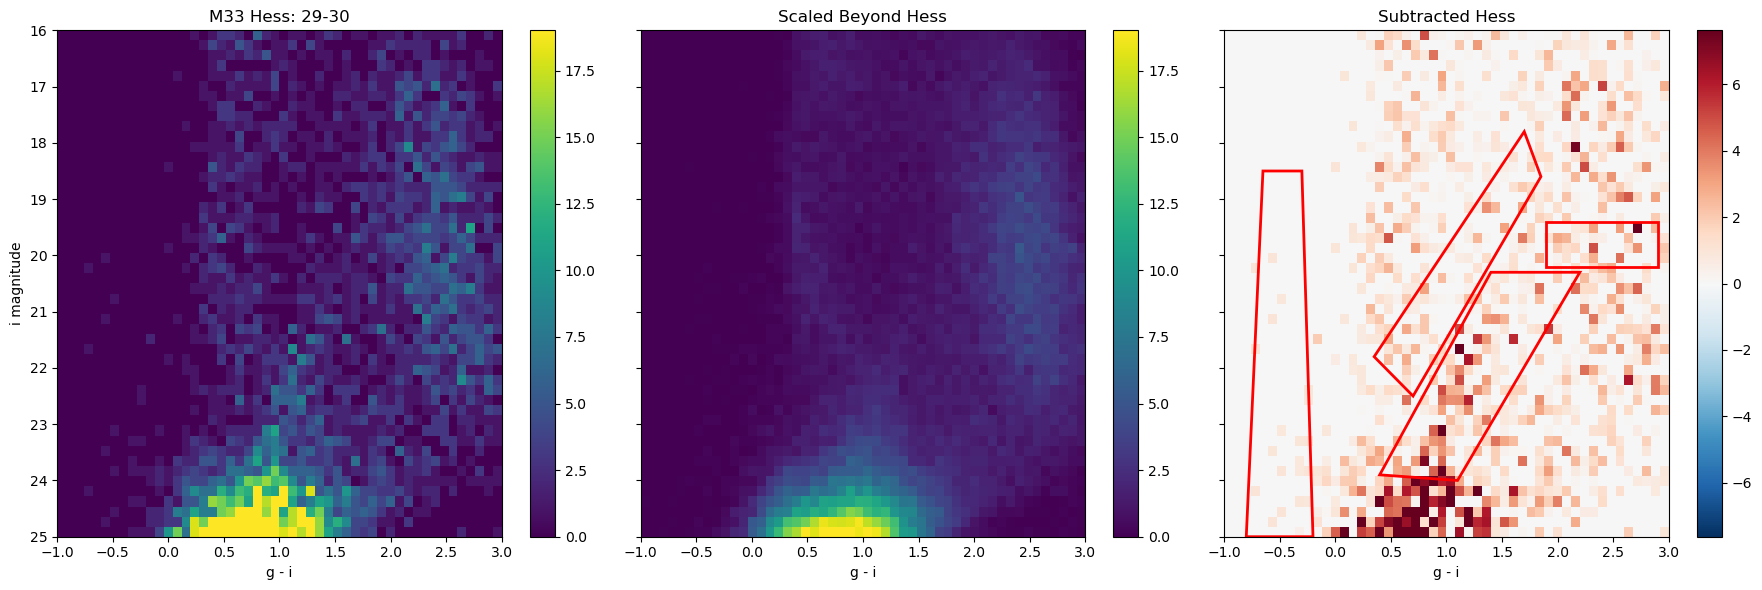

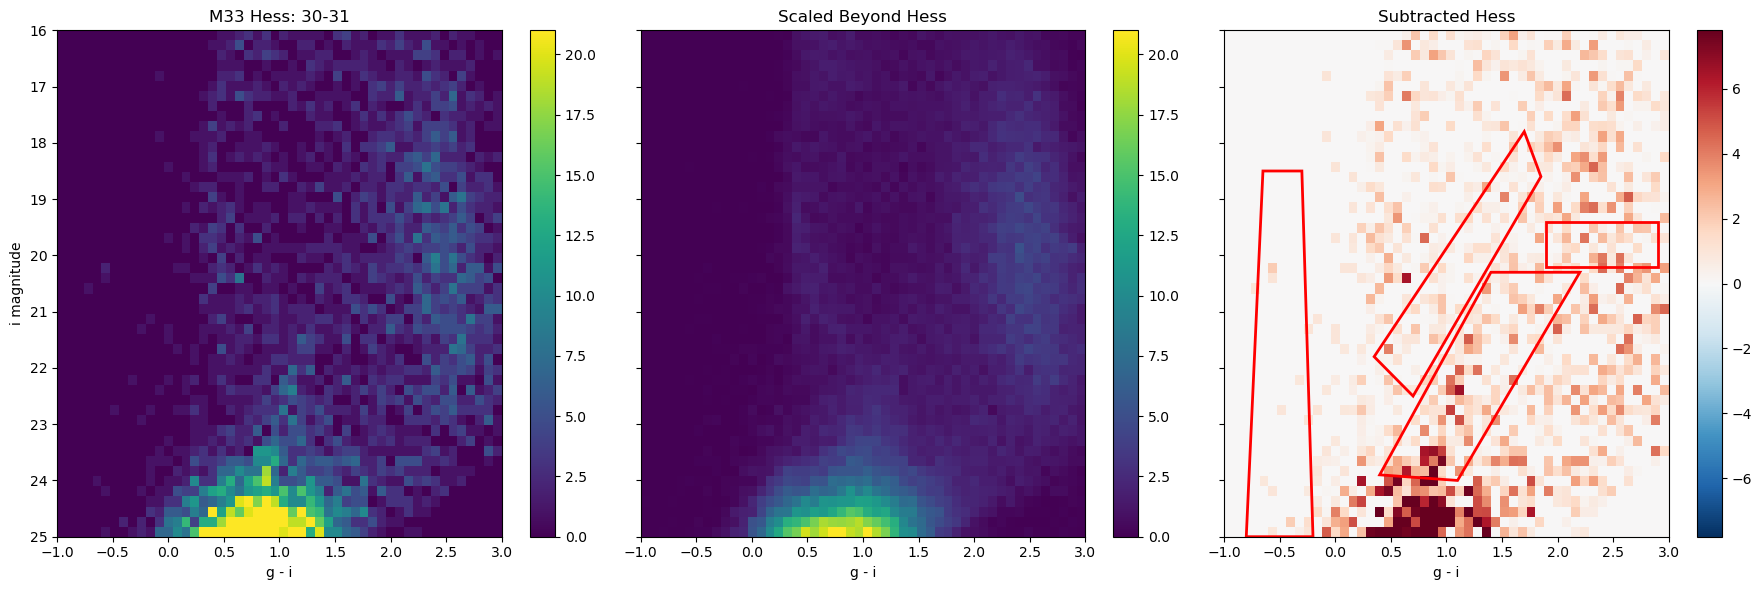

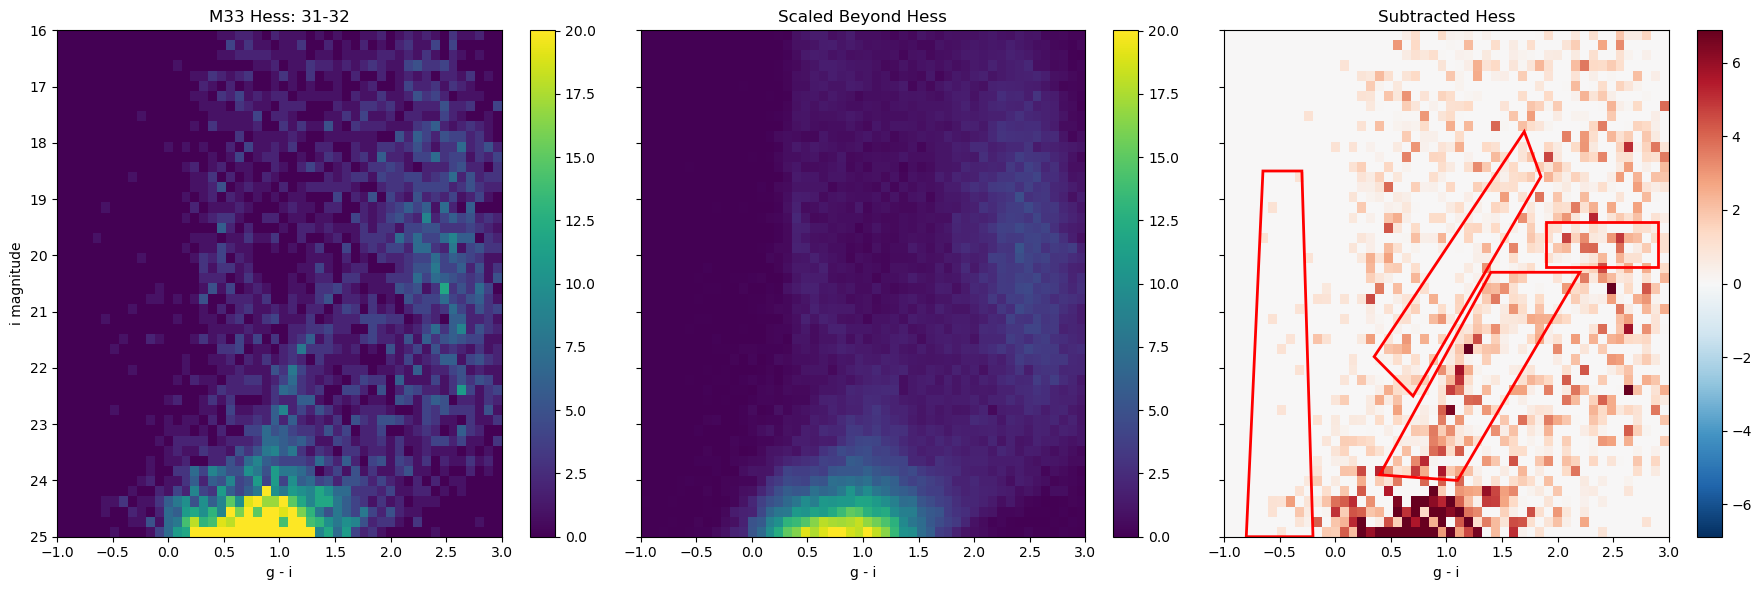

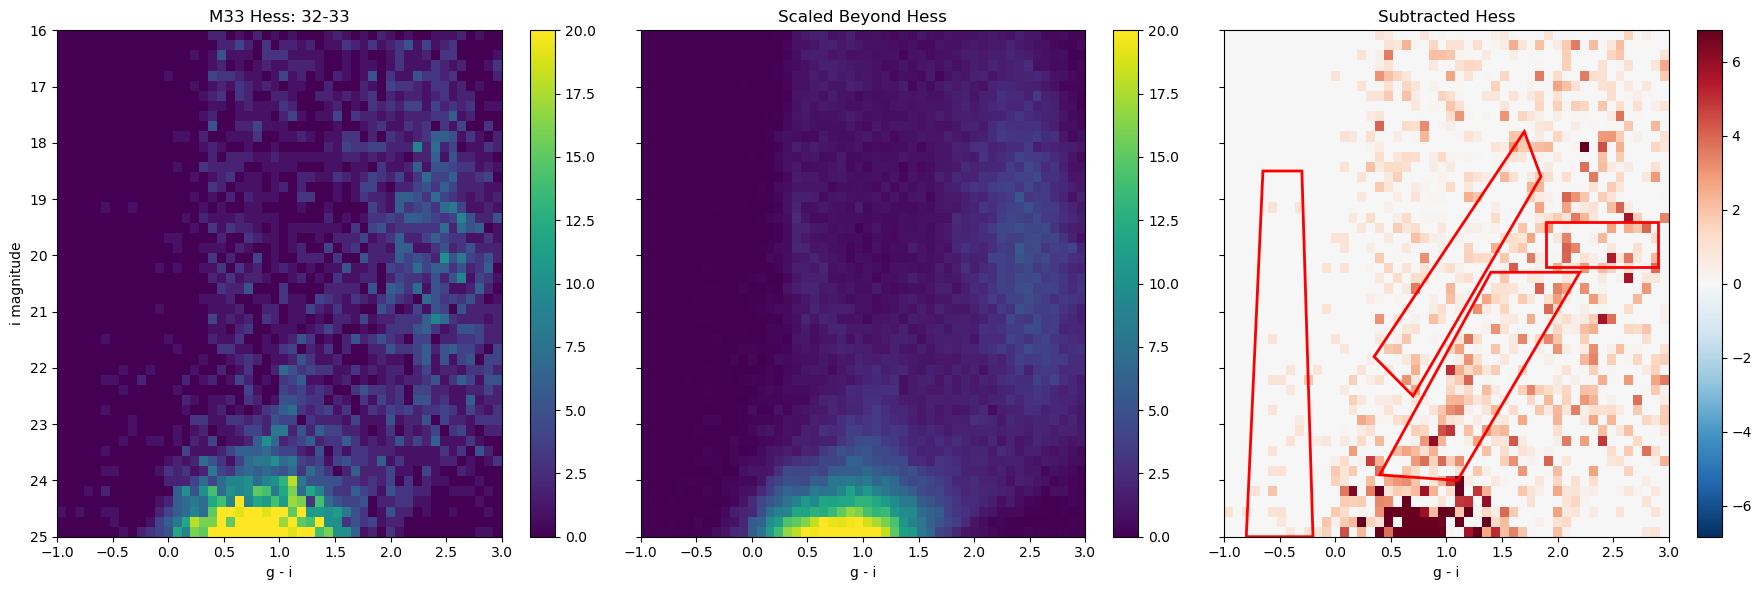

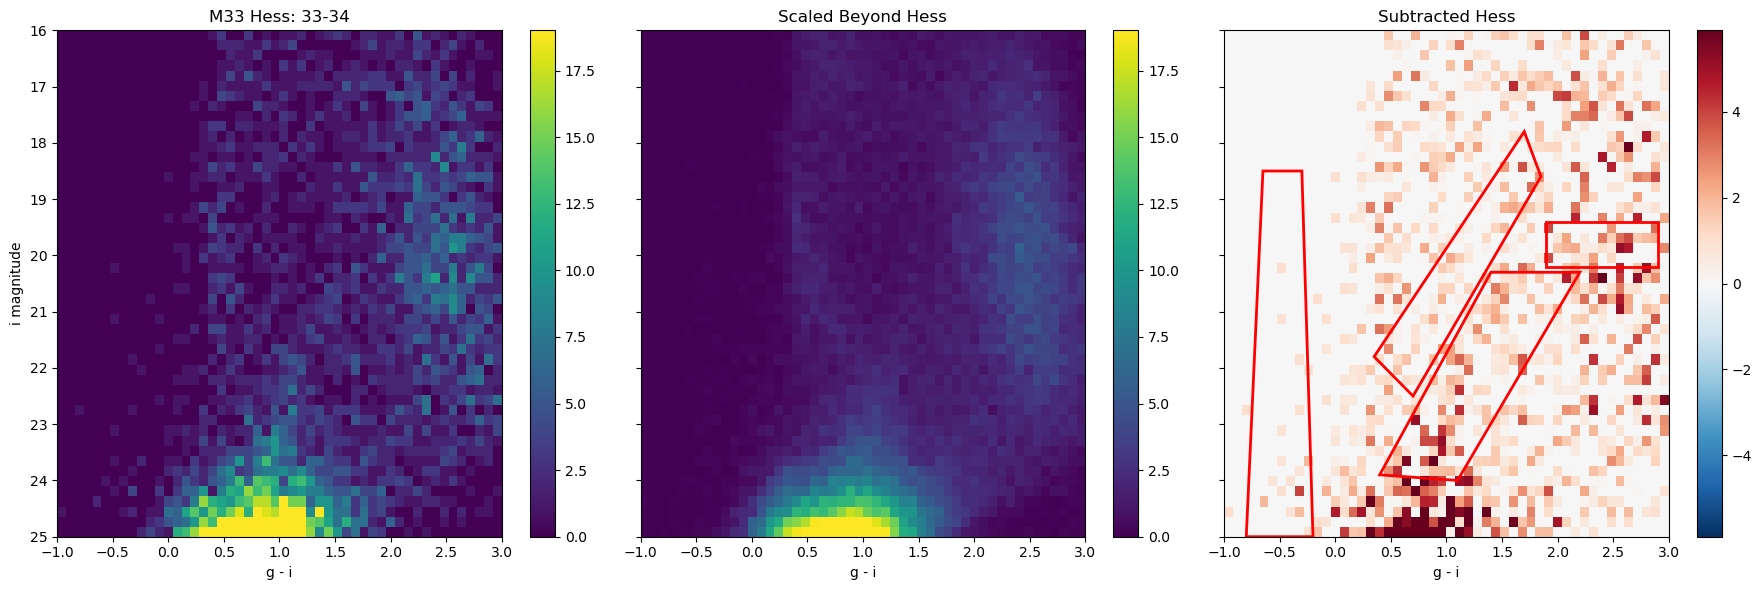

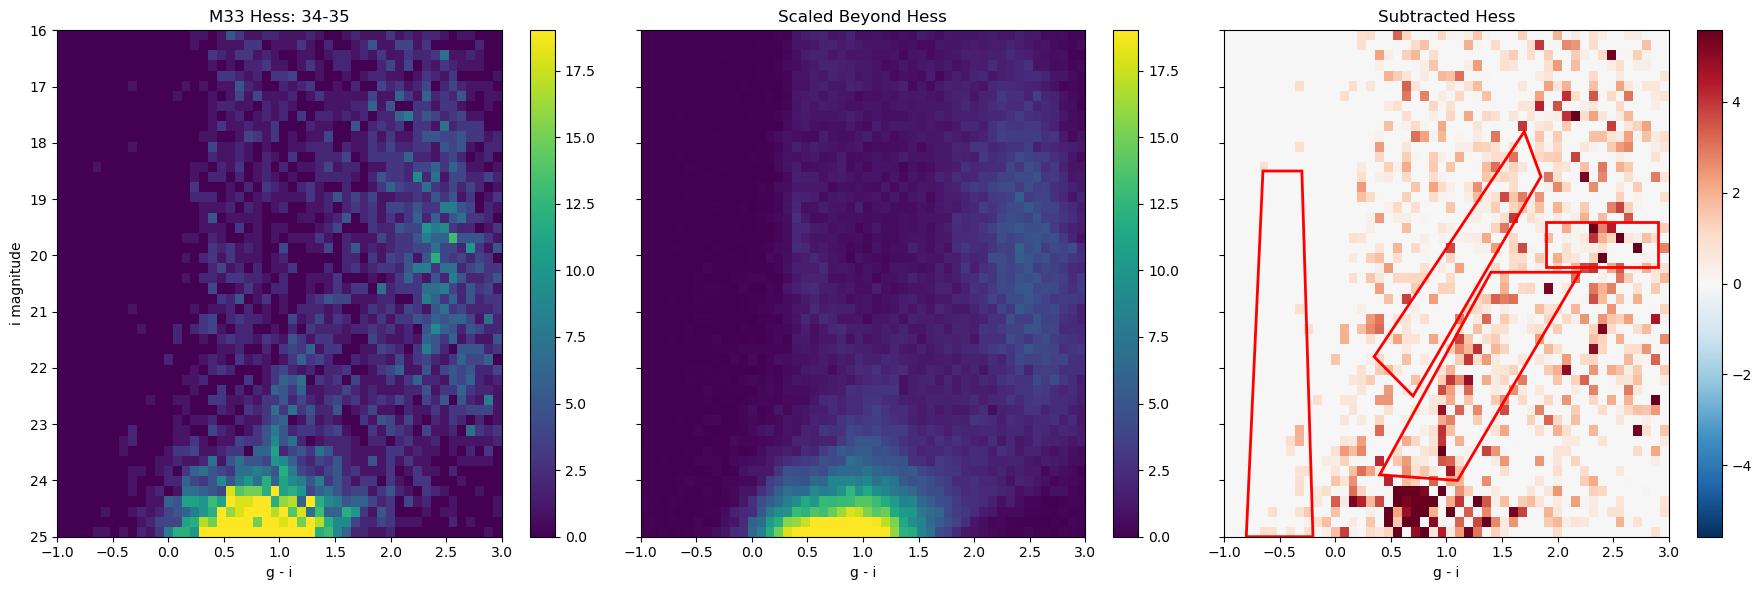

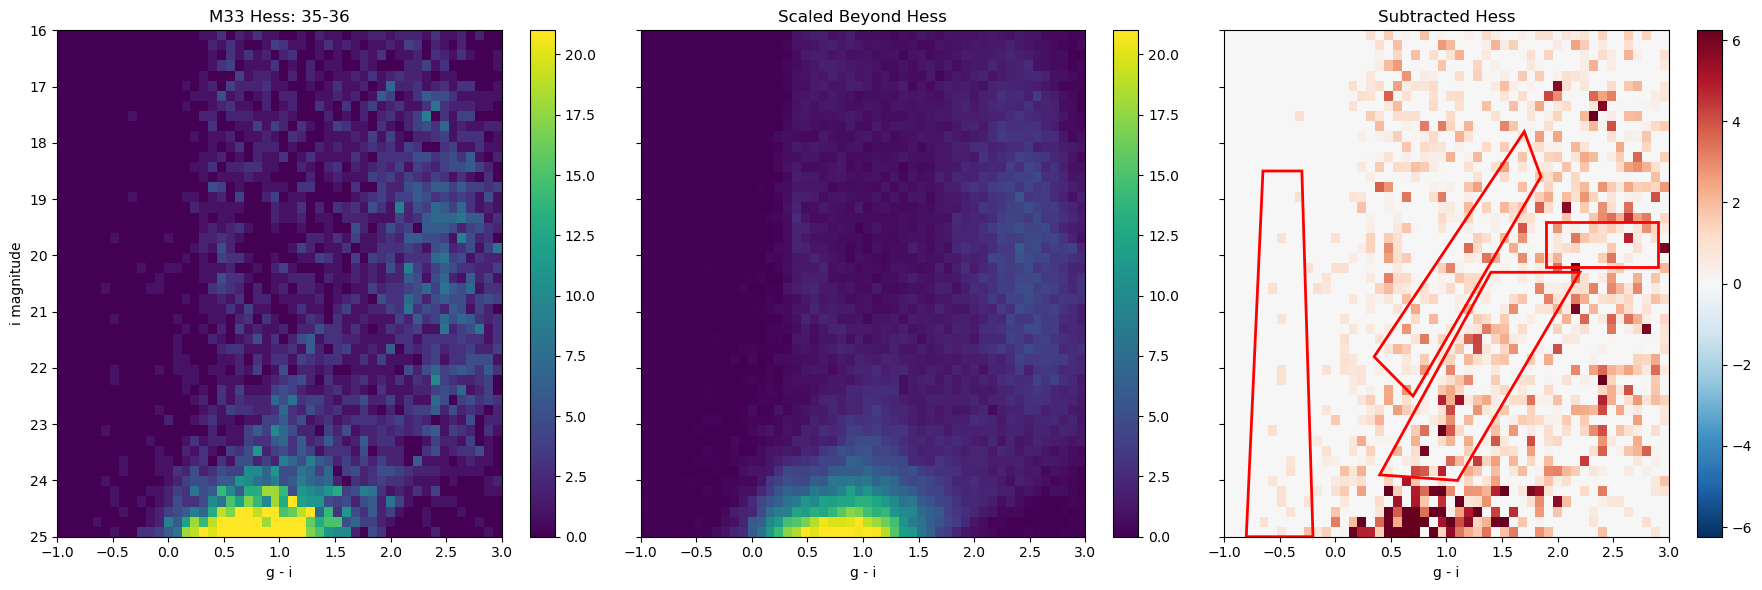

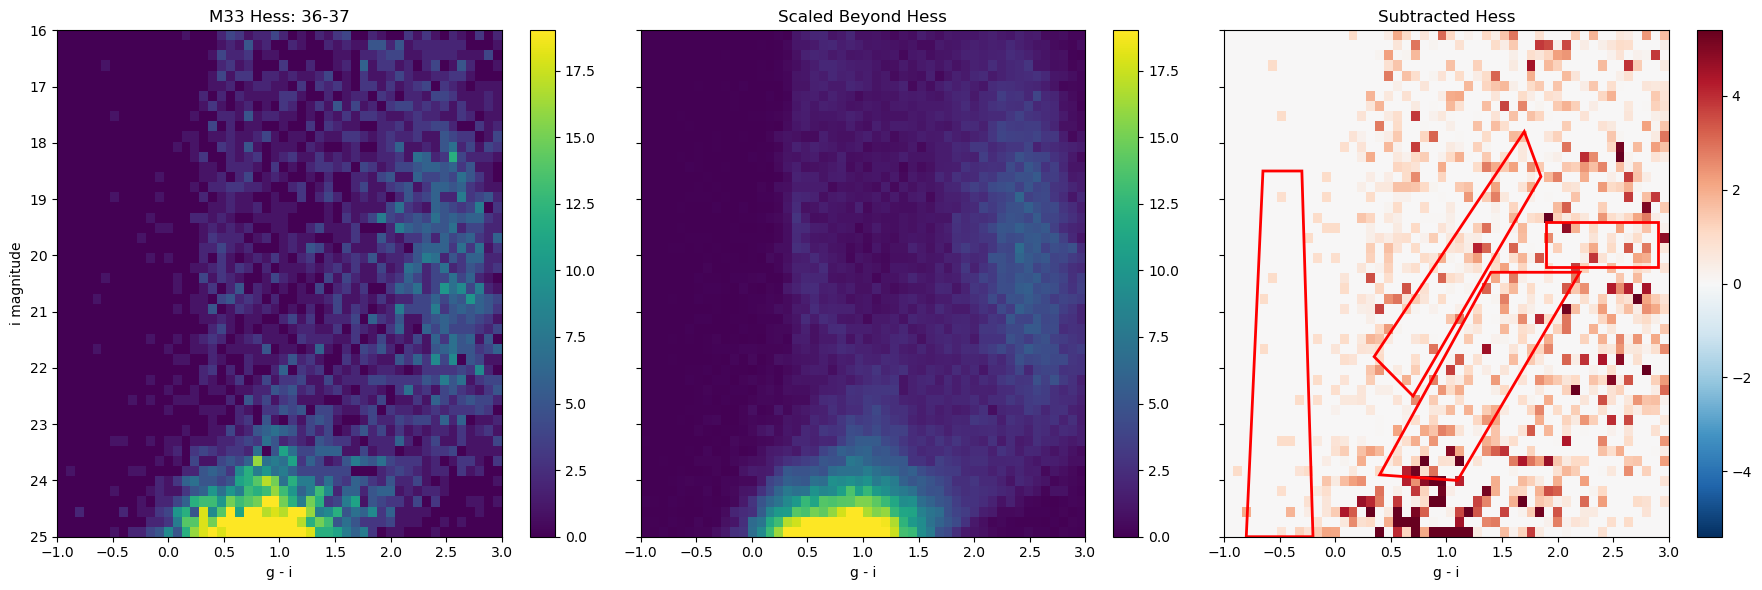

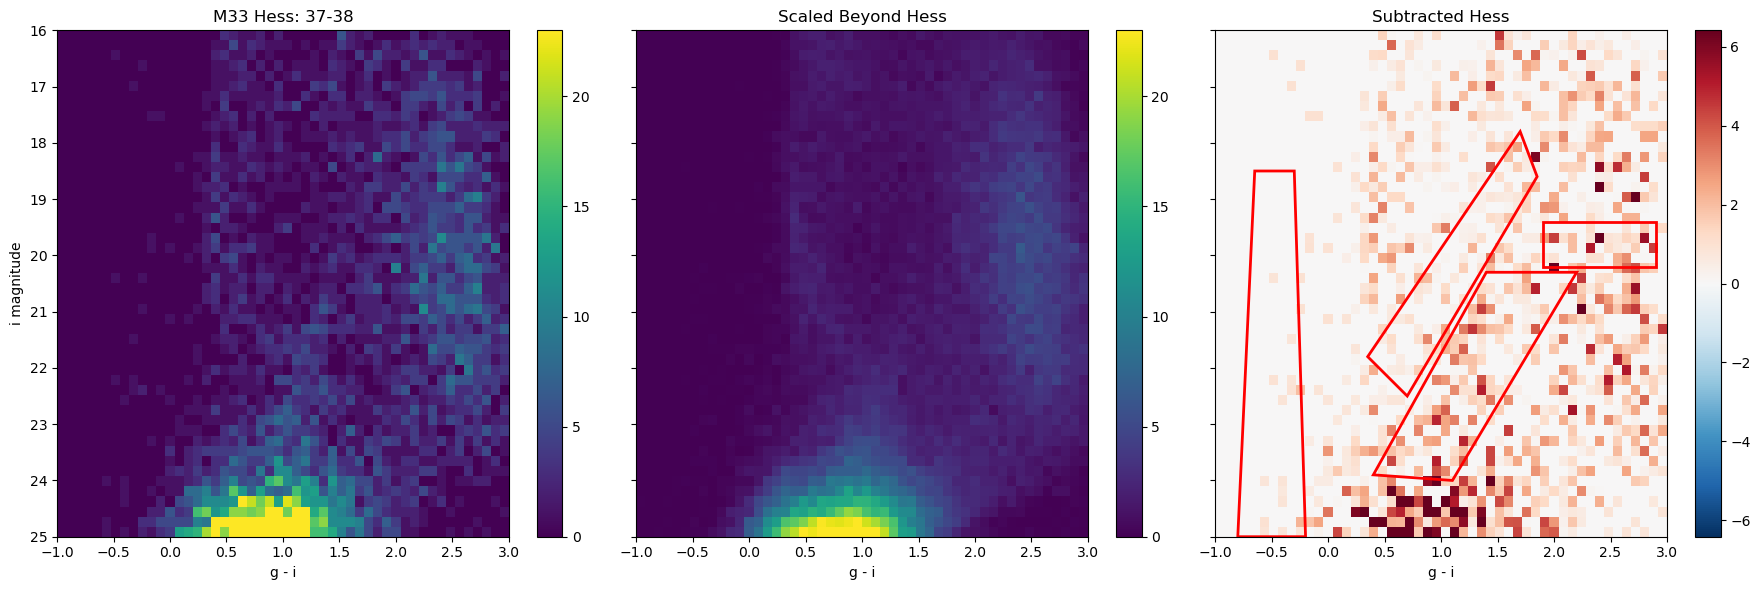

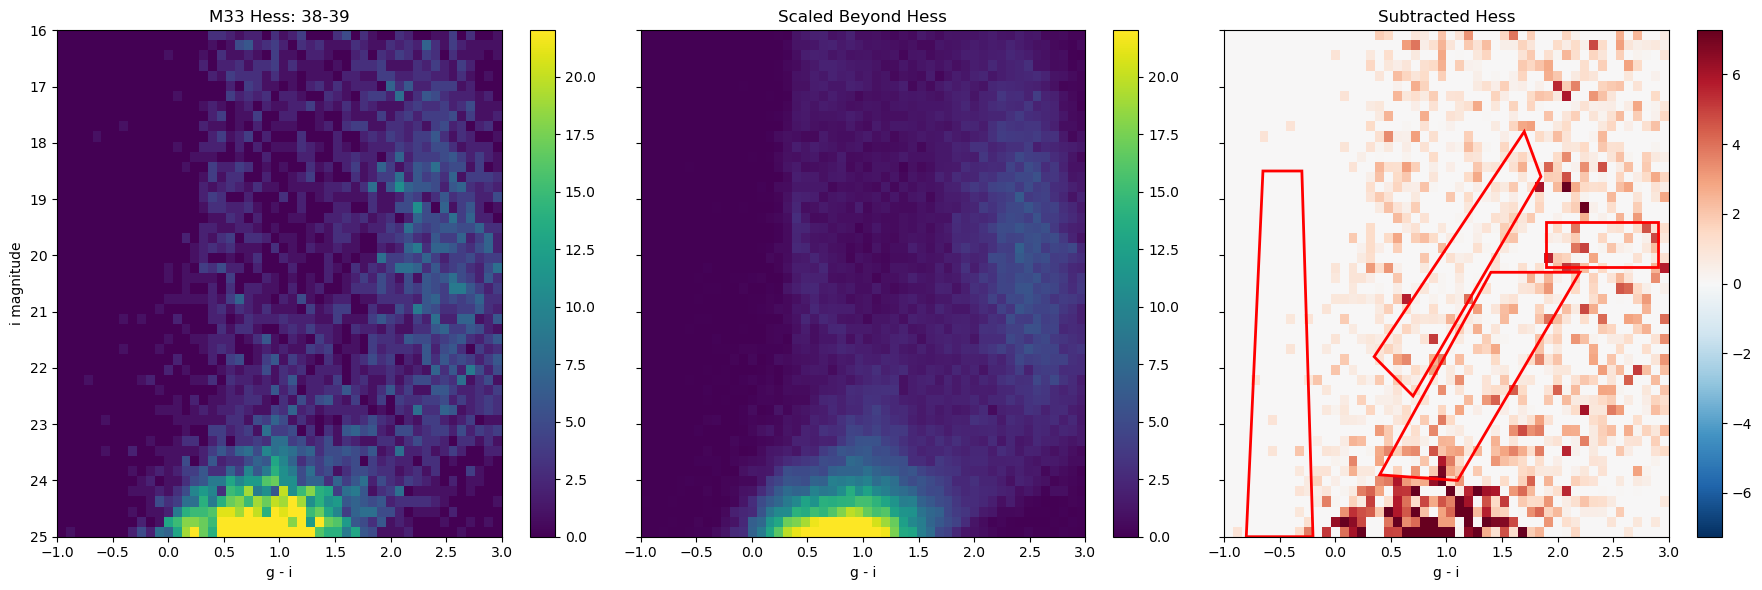

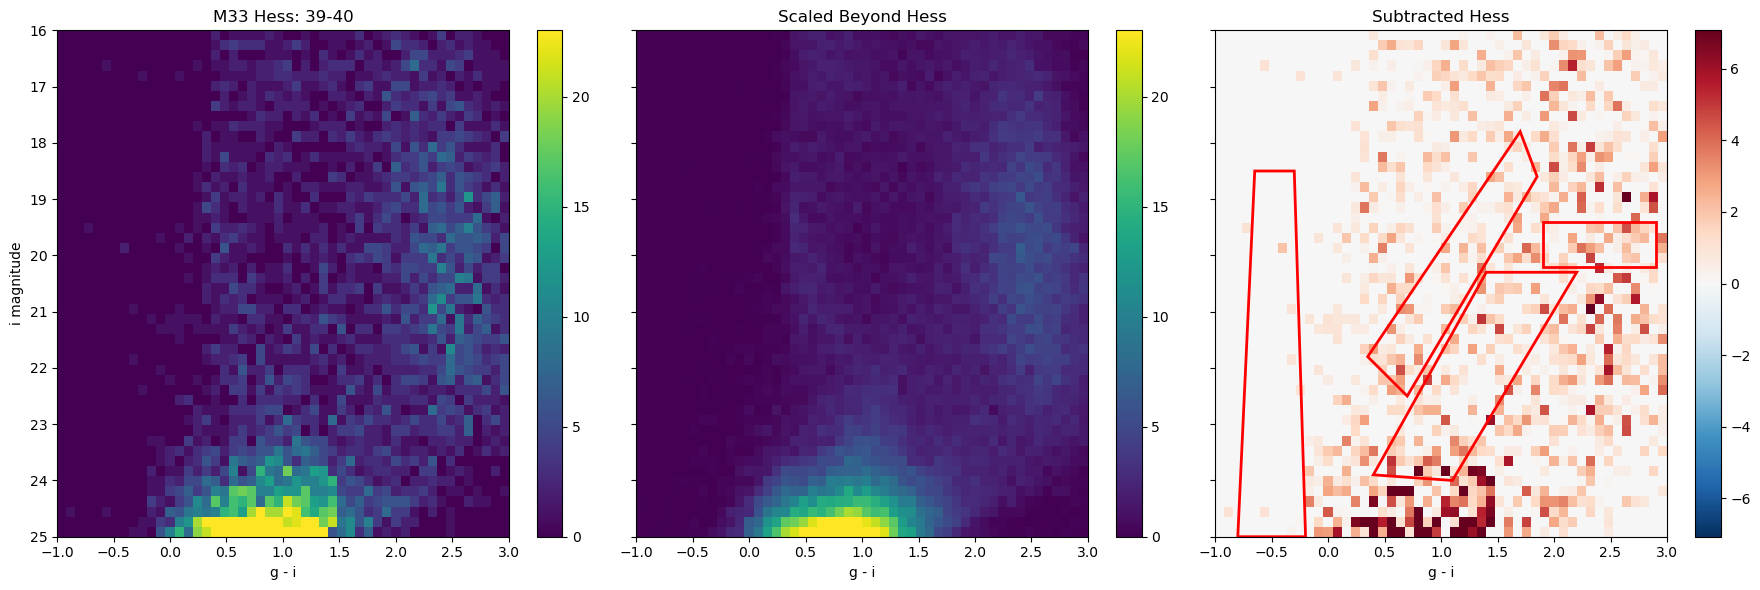

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Polygon

# === Load processed CSV data ===
panda = pd.read_csv("panda_deproj.csv")

# === Define Area Functions ===
def elliptical_annulus_area_analytic(a_in_kpc, a_out_kpc, inc_deg):
    inc_rad = np.deg2rad(inc_deg)
    return np.pi * (a_out_kpc**2 - a_in_kpc**2) * np.cos(inc_rad)

def estimate_area_and_plot_annuli(n_points=1_00_000, max_radius_kpc=60,
                                   distance_kpc=859, PA_deg=112, inc_deg=52,
                                   area_rings=[], plot_radii_kpc=[]):
    def kpc_to_arcmin(kpc):
        return np.rad2deg(kpc / distance_kpc) * 60

    max_radius_rad = max_radius_kpc / distance_kpc
    max_radius_arcmin = np.rad2deg(max_radius_rad) * 60
    xi = np.random.uniform(-max_radius_arcmin, max_radius_arcmin, n_points)
    eta = np.random.uniform(-max_radius_arcmin, max_radius_arcmin, n_points)

    PA_rad = np.deg2rad(PA_deg)
    inc_rad = np.deg2rad(inc_deg)
    xi_rot = xi * np.cos(PA_rad) + eta * np.sin(PA_rad)
    eta_rot = -xi * np.sin(PA_rad) + eta * np.cos(PA_rad)
    eta_deproj = eta_rot / np.cos(inc_rad)
    r_arcmin = np.sqrt(xi_rot**2 + eta_deproj**2)

    areas = {}
    for a_in_kpc, a_out_kpc in area_rings:
        r_in = kpc_to_arcmin(a_in_kpc)
        r_out = kpc_to_arcmin(a_out_kpc)
        mask = (r_arcmin >= r_in) & (r_arcmin < r_out)
        n_inside = np.sum(mask)
        box_area_arcmin2 = (2 * max_radius_arcmin)**2
        arcmin2_to_sr = (np.pi / (180 * 60))**2
        box_area_sr = box_area_arcmin2 * arcmin2_to_sr
        box_area_kpc2 = box_area_sr * (distance_kpc ** 2)
        area_estimate = (n_inside / n_points) * box_area_kpc2
        areas[f"{a_in_kpc}-{a_out_kpc}"] = area_estimate

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(xi, eta, s=0.2, alpha=0.3, label='Random Points')
    for r_kpc in plot_radii_kpc:
        a = kpc_to_arcmin(r_kpc)
        b = a * np.cos(inc_rad)
        color = 'blue' if r_kpc < 40 else 'red'
        style = '--' if r_kpc % 2 == 0 else '-'
        ellipse = Ellipse((0, 0), width=2*a, height=2*b, angle=PA_deg,
                          edgecolor=color, linestyle=style, fill=False, label=f"{r_kpc} kpc")
        ax.add_patch(ellipse)

    ax.set_xlabel("ξ (arcmin)")
    ax.set_ylabel("η (arcmin)")
    ax.set_title("Deprojected Elliptical Annuli with Random Points")
    ax.set_aspect('equal')
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    return areas

def make_hess(df, bins=(50, 50)):
    hist, xedges, yedges = np.histogram2d(df['color'], df['mag'], bins=bins, range=[[-1, 3], [18, 25]])
    return hist

# === Define bins (2 kpc steps beyond 15) ===
radial_bins_kpc = [(3, 10), (10, 13), (13, 15)] + [(r, r + 1) for r in range(15, 40)]
beyond_bin = (40, 50)
all_bins = radial_bins_kpc + [beyond_bin]

area_results = estimate_area_and_plot_annuli(
    n_points=100_000,
    max_radius_kpc=60,
    distance_kpc=859,
    PA_deg=112,
    inc_deg=52,
    area_rings=all_bins,
    plot_radii_kpc=[r for pair in all_bins for r in pair]
)

# === Print Area Comparison Table ===
print("\n=== Area Comparison for All Bins ===")
print(f"{'Bin (kpc)':<12} {'Analytic Area':>20} {'Monte Carlo Area':>25} {'% Diff':>10}")
print("-" * 75)
for (r_in, r_out) in all_bins:
    key = f"{r_in}-{r_out}"
    area_mc = area_results[key]
    area_an = elliptical_annulus_area_analytic(r_in, r_out, inc_deg=52)
    pct_diff = 100 * (area_mc - area_an) / area_an
    print(f"{key:<12} {area_an:>20.2f} {area_mc:>25.2f} {pct_diff:>10.2f}")

# === Subtract and Plot Hess Diagrams in Linear Scale ===
beyond_area = area_results[f"{beyond_bin[0]}-{beyond_bin[1]}"]
beyond_df = panda[(panda['r_deproj_kpc'] >= beyond_bin[0]) & (panda['r_deproj_kpc'] < beyond_bin[1])]
hess_beyond = make_hess(beyond_df)

for r_in, r_out in radial_bins_kpc:
    label = f"{r_in}-{r_out}"
    bin_df = panda[(panda['r_deproj_kpc'] >= r_in) & (panda['r_deproj_kpc'] < r_out)]
    hess_m33 = make_hess(bin_df)

    scale = area_results[label] / beyond_area
    hess_scaled_beyond = scale * hess_beyond
    hess_subtracted = hess_m33 - hess_scaled_beyond

    vlim = np.percentile(np.abs(hess_m33), 99)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    im0 = axes[0].imshow(hess_m33.T, origin='upper', aspect='auto',
                         extent=[-1, 3, 25, 16], cmap='viridis',
                         vmin=0, vmax=vlim)
    axes[0].set_title(f"M33 Hess: {label}")
    axes[0].set_xlabel('g - i')
    axes[0].set_ylabel('i magnitude')
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(hess_scaled_beyond.T, origin='upper', aspect='auto',
                         extent=[-1, 3, 25, 16], cmap='viridis',
                         vmin=0, vmax=vlim)
    axes[1].set_title("Scaled Beyond Hess")
    axes[1].set_xlabel('g - i')
    fig.colorbar(im1, ax=axes[1])

    vlim_diff = np.percentile(np.abs(hess_subtracted), 99)
    hess_subtracted_clipped = np.clip(hess_subtracted, 0, None)
    im2 = axes[2].imshow(hess_subtracted_clipped.T, origin='upper', aspect='auto',
                        extent=[-1, 3, 25, 16], cmap='RdBu_r',
                        vmin=-vlim_diff, vmax=vlim_diff)
    axes[2].set_title("Subtracted Hess")
    axes[2].set_xlabel('g - i')
    fig.colorbar(im2, ax=axes[2])

    # === Add Estimated Red Polygons ===
    polygon_regions = [
        [(-0.8, 25), (-0.65, 18.5), (-0.3, 18.5), (-0.2, 25)],
        [(0.7, 22.5), (0.35, 21.8), (1.7, 17.8), (1.85, 18.6)],
        [(0.4, 23.9), (1.4, 20.3), (2.2, 20.3), (1.1, 24)],
        [(1.9, 19.4), (2.9, 19.4), (2.9, 20.2), (1.9, 20.2)]
    ]
    for poly in polygon_regions:
        patch = Polygon(poly, closed=True, edgecolor='red', facecolor='none', linewidth=2)
        axes[2].add_patch(patch)

    plt.tight_layout()
    plt.show()